In [39]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_PATH = '/content/drive/MyDrive/ML final project/ML_final'

if not os.path.exists(PROJECT_PATH):
    os.makedirs(PROJECT_PATH)
    print(f"it created: {PROJECT_PATH}")

%cd {PROJECT_PATH}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ML final project/ML_final


In [2]:
!pip install mlflow
!pip install dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 131.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 99.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import dagshub
dagshub.init(repo_owner='mesata', repo_name='Walmart---Store-Sales-Forecasting', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=9c1746d9-f9b9-4275-a78c-4d6d87a996b6&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=3c027d750045b50f9b7754917dc9f53f95426c5a4aaddb5024cb283694cf635b




Accessing as mkekn23

Initialized MLflow to track repo "mesata/Walmart---Store-Sales-Forecasting"

Repository mesata/Walmart---Store-Sales-Forecasting initialized!

In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import mlflow
import mlflow.sklearn

In [5]:
train_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/train.csv.zip')
features_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/features.csv.zip')
stores_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/stores.csv')

In [6]:
from walmart_transformers import WalmartDataTransformer,TimeSeriesSplitter

### Data Preparation for Prophet Baseline

First, we'll preprocess the data using the `WalmartDataTransformer` to merge the datasets and prepare them for Prophet. Prophet requires a DataFrame with `ds` (datestamp) and `y` (target) columns.

In [ ]:
transformer = WalmartDataTransformer(features_df=features_df, stores_df=stores_df)

# Assuming the transformer has a method to merge and preprocess data
# Adjust method call and arguments based on the actual implementation of WalmartDataTransformer
# For this baseline, we'll focus on overall weekly sales without splitting by store/dept initially.
# We will aggregate to get a single time series for the baseline.

# Merge dataframes (this might be handled internally by the transformer if it's more complex)
merged_df = train_df.merge(features_df, on=['Store', 'Date', 'IsHoliday'], how='left')
merged_df = merged_df.merge(stores_df, on=['Store'], how='left')

# Convert Date to datetime
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

# Aggregate weekly sales for a simple baseline (total sales across all stores/departments)
# Prophet works best on a single time series. We will create an overall sales series.
prophet_df = merged_df.groupby('Date')['Weekly_Sales'].sum().reset_index()

# Rename columns for Prophet
prophet_df = prophet_df.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})

display(prophet_df.head())

In [ ]:
prophet_df = merged_df.groupby('Date').agg(
    y=('Weekly_Sales', 'sum'),
    IsHoliday=('IsHoliday', 'first') # Assuming IsHoliday is consistent per date
).reset_index()
prophet_df = prophet_df.rename(columns={'Date': 'ds'})

display(prophet_df.head())

### Prophet Baseline Model Class

We will define a `ProphetBaseline` class that wraps the Prophet model, making it compatible with scikit-learn's `Pipeline` API (though we might not use a full `Pipeline` for this simple baseline, it's good practice for modularity).

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
from prophet import Prophet

class ProphetBaseline(BaseEstimator, RegressorMixin):
    def __init__(self, seasonality_mode='additive', growth='linear', weekly_seasonality=True, daily_seasonality=False, yearly_seasonality=True):
        self.seasonality_mode = seasonality_mode
        self.growth = growth
        self.weekly_seasonality = weekly_seasonality
        self.daily_seasonality = daily_seasonality
        self.yearly_seasonality = yearly_seasonality
        self.model = None

    def fit(self, X, y=None):
        # Prophet expects 'ds' and 'y' columns
        # X should already be in the format {ds: ..., y: ...}
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=['ds', 'y'])

        self.model = Prophet(
            seasonality_mode=self.seasonality_mode,
            growth=self.growth,
            weekly_seasonality=self.weekly_seasonality,
            daily_seasonality=self.daily_seasonality,
            yearly_seasonality=self.yearly_seasonality
        )
        self.model.fit(X)
        return self

    def predict(self, X):
        # X should be a DataFrame with 'ds' column for future dates
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=['ds'])

        future = X[['ds']]
        forecast = self.model.predict(future)
        return forecast['yhat'].values


### Training and MLflow Logging Function

Now, let's define a function to train the Prophet baseline model, evaluate it, and log the results to MLflow. We'll split the data into training and validation sets for evaluation.

In [ ]:
def wmae_metric(y_true, y_pred, is_holiday):
    # Weights are 5 for holidays, 1 otherwise
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


In [ ]:
def train_prophet_baseline(df: pd.DataFrame, test_size: int = 52, run_name: str = "Prophet Baseline"):
    """
    Trains a Prophet baseline model, evaluates it, and logs to MLflow.

    Args:
        df (pd.DataFrame): DataFrame with 'ds' (datestamp) and 'y' (target) columns.
        test_size (int): Number of weeks to use for the test set.
        run_name (str): Name for the MLflow run.
    """
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("model_type", "Prophet")

        # Split data into train and test sets
        train_df = df[:-test_size]
        test_df = df[-test_size:]

        mlflow.log_param("train_start_date", train_df['ds'].min())
        mlflow.log_param("train_end_date", train_df['ds'].max())
        mlflow.log_param("test_start_date", test_df['ds'].min())
        mlflow.log_param("test_end_date", test_df['ds'].max())

        # Initialize and train the Prophet model
        prophet_model = ProphetBaseline(
            seasonality_mode='additive',
            weekly_seasonality=True,
            yearly_seasonality=True,
            daily_seasonality=False
        )
        prophet_model.fit(train_df)

        # Log Prophet parameters
        mlflow.log_params({
            "seasonality_mode": prophet_model.seasonality_mode,
            "growth": prophet_model.growth,
            "weekly_seasonality": prophet_model.weekly_seasonality,
            "daily_seasonality": prophet_model.daily_seasonality,
            "yearly_seasonality": prophet_model.yearly_seasonality
        })

        # Make predictions on the test set
        predictions = prophet_model.predict(test_df[['ds']])

        # Evaluate the model
        mae = mean_absolute_error(test_df['y'], predictions)
        mlflow.log_metric("mae", mae)

        print(f"Prophet Baseline MAE: {mae:.2f}")

        # Log the model
        # Prophet models can be logged directly using mlflow.prophet.log_model
        # However, since we wrapped it, we'll log the wrapped sklearn model.
        # The `ProphetBaseline` class implements `fit` and `predict` similar to sklearn models.
        mlflow.sklearn.log_model(prophet_model, "prophet_baseline_model", serialization_format='cloudpickle')

        print(f"MLflow Run ID: {mlflow.active_run().info.run_id}")


In [ ]:
def train_prophet_baseline(df: pd.DataFrame, test_size: int = 52, run_name: str = "Prophet Baseline"):
    """
    Trains a Prophet baseline model, evaluates it using WMAE, and logs to MLflow.

    Args:
        df (pd.DataFrame): DataFrame with 'ds' (datestamp), 'y' (target), and 'IsHoliday' columns.
        test_size (int): Number of weeks to use for the test set.
        run_name (str): Name for the MLflow run.
    """
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("model_type", "Prophet")

        # Split data into train and test sets
        train_df = df[:-test_size]
        test_df = df[-test_size:]

        mlflow.log_param("train_start_date", train_df['ds'].min())
        mlflow.log_param("train_end_date", train_df['ds'].max())
        mlflow.log_param("test_start_date", test_df['ds'].min())
        mlflow.log_param("test_end_date", test_df['ds'].max())

        # Initialize and train the Prophet model
        prophet_model = ProphetBaseline(
            seasonality_mode='additive',
            weekly_seasonality=True,
            yearly_seasonality=True,
            daily_seasonality=False
        )
        prophet_model.fit(train_df[['ds', 'y']]) # Prophet only needs 'ds' and 'y' for fitting

        # Log Prophet parameters
        mlflow.log_params({
            "seasonality_mode": prophet_model.seasonality_mode,
            "growth": prophet_model.growth,
            "weekly_seasonality": prophet_model.weekly_seasonality,
            "daily_seasonality": prophet_model.daily_seasonality,
            "yearly_seasonality": prophet_model.yearly_seasonality
        })

        # Make predictions on the training and test sets
        train_predictions = prophet_model.predict(train_df[['ds']])
        test_predictions = prophet_model.predict(test_df[['ds']])

        # Evaluate the model using WMAE
        train_wmae = wmae_metric(train_df['y'], train_predictions, train_df['IsHoliday'])
        test_wmae = wmae_metric(test_df['y'], test_predictions, test_df['IsHoliday'])

        mlflow.log_metric("train_wmae", train_wmae)
        mlflow.log_metric("test_wmae", test_wmae)

        print(f"Prophet Baseline Train WMAE: {train_wmae:.2f}")
        print(f"Prophet Baseline Test WMAE: {test_wmae:.2f}")

        # Log the model
        mlflow.sklearn.log_model(prophet_model, "prophet_baseline_model", serialization_format='cloudpickle')

        print(f"MLflow Run ID: {mlflow.active_run().info.run_id}")


### Execute Prophet Baseline Training and Logging

In [ ]:
mlflow.set_experiment("prophet")

In [ ]:
# Train and log the Prophet baseline model
# Using 52 weeks (1 year) for the test set as requested
train_prophet_baseline(prophet_df, test_size=52)

### Prophet Baseline with Multiplicative Seasonality Mode

Let's try training the Prophet model again, but this time with `seasonality_mode='multiplicative'`, which can be more appropriate when seasonal effects grow or shrink proportionally with the trend.

In [ ]:
def train_prophet_baseline_multiplicative(df: pd.DataFrame, test_size: int = 52, run_name: str = "Prophet Baseline Multiplicative"):
    """
    Trains a Prophet baseline model with multiplicative seasonality, evaluates it using WMAE, and logs to MLflow.

    Args:
        df (pd.DataFrame): DataFrame with 'ds' (datestamp), 'y' (target), and 'IsHoliday' columns.
        test_size (int): Number of weeks to use for the test set.
        run_name (str): Name for the MLflow run.
    """
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("model_type", "Prophet")

        # Split data into train and test sets
        train_df = df[:-test_size]
        test_df = df[-test_size:]

        mlflow.log_param("train_start_date", train_df['ds'].min())
        mlflow.log_param("train_end_date", train_df['ds'].max())
        mlflow.log_param("test_start_date", test_df['ds'].min())
        mlflow.log_param("test_end_date", test_df['ds'].max())

        # Initialize and train the Prophet model with multiplicative seasonality
        prophet_model = ProphetBaseline(
            seasonality_mode='multiplicative',
            weekly_seasonality=True,
            yearly_seasonality=True,
            daily_seasonality=False
        )
        prophet_model.fit(train_df[['ds', 'y']])

        # Log Prophet parameters
        mlflow.log_params({
            "seasonality_mode": prophet_model.seasonality_mode,
            "growth": prophet_model.growth,
            "weekly_seasonality": prophet_model.weekly_seasonality,
            "daily_seasonality": prophet_model.daily_seasonality,
            "yearly_seasonality": prophet_model.yearly_seasonality
        })

        # Make predictions on the training and test sets
        train_predictions = prophet_model.predict(train_df[['ds']])
        test_predictions = prophet_model.predict(test_df[['ds']])

        # Evaluate the model using WMAE
        train_wmae = wmae_metric(train_df['y'], train_predictions, train_df['IsHoliday'])
        test_wmae = wmae_metric(test_df['y'], test_predictions, test_df['IsHoliday'])

        mlflow.log_metric("train_wmae", train_wmae)
        mlflow.log_metric("test_wmae", test_wmae)

        print(f"Prophet Baseline Multiplicative Train WMAE: {train_wmae:.2f}")
        print(f"Prophet Baseline Multiplicative Test WMAE: {test_wmae:.2f}")

        # Log the model
        mlflow.sklearn.log_model(prophet_model, "prophet_baseline_model_multiplicative", serialization_format='cloudpickle')

        print(f"MLflow Run ID: {mlflow.active_run().info.run_id}")

# Call the new training function
train_prophet_baseline_multiplicative(prophet_df, test_size=52)

In [7]:
DATA_DIR = '/content/drive/MyDrive/ML final project/walmart_data/'
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv.zip")
TEST_PATH = os.path.join(DATA_DIR, "test.csv.zip")
FEATURES_PATH = os.path.join(DATA_DIR, "features.csv.zip")
STORES_PATH = os.path.join(DATA_DIR, "stores.csv")

# Adjust MLFLOW_TRACKING_URI if needed, based on previous dagshub.init
MLFLOW_TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", "https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow")
EXPERIMENT_NAME = "walmart-sales-forecasting"
RUN_NAME = "prophet-per-store-dept"

REGRESSORS = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "MarkDown_total"]

In [8]:
import warnings
from tqdm import tqdm
from prophet import Prophet

warnings.filterwarnings("ignore")

def load_data():
    # Use the globally defined paths to load data
    train = pd.read_csv(TRAIN_PATH, parse_dates=["Date"])
    test = pd.read_csv(TEST_PATH, parse_dates=["Date"])
    features = pd.read_csv(FEATURES_PATH, parse_dates=["Date"])
    stores = pd.read_csv(STORES_PATH)

    markdown_cols = [c for c in features.columns if c.startswith("MarkDown")]
    features["MarkDown_total"] = features[markdown_cols].fillna(0).sum(axis=1)

    features = features.merge(stores, on="Store", how="left")

    train = train.merge(
        features.drop(columns=["IsHoliday"], errors="ignore"),
        on=["Store", "Date"], how="left"
    )
    test = test.merge(
        features.drop(columns=["IsHoliday"], errors="ignore"),
        on=["Store", "Date"], how="left"
    )

    for df in (train, test):
        for col in REGRESSORS:
            if col in df.columns:
                df[col] = df[col].fillna(df[col].median())

    return train, test

def build_holidays(train: pd.DataFrame) -> pd.DataFrame:
    """IsHoliday=True მქონე თარიღები Prophet-ის holiday ფორმატში."""
    holiday_dates = train.loc[train["IsHoliday"] == True, "Date"].unique()
    holidays = pd.DataFrame({
        "holiday": "walmart_holiday_week",
        "ds": pd.to_datetime(holiday_dates),
        "lower_window": 0,
        "upper_window": 0,
    })
    return holidays

# def fit_predict_one_series(group_train: pd.DataFrame,
#                             group_test: pd.DataFrame,
#                             holidays: pd.DataFrame) -> pd.DataFrame:
#     df = group_train.rename(columns={"Date": "ds", "Weekly_Sales": "y"})[
#         ["ds", "y"] + [c for c in REGRESSORS if c in group_train.columns]
#     ].sort_values("ds")

#     if len(df) < 10:
#         # ძალიან მოკლე სერიაზე Prophet-ს აზრი არ აქვს - საშუალო მნიშვნელობით ვავსებთ
#         fallback = group_train["Weekly_Sales"].mean() if len(group_train) else 0.0
#         out = group_test[["Store", "Dept", "Date", "IsHoliday"]].copy() # Added IsHoliday
#         out["Weekly_Sales_Pred"] = fallback
#         return out

#     m = Prophet(
#         holidays=holidays,
#         yearly_seasonality=True,
#         weekly_seasonality=False,
#         daily_seasonality=False,
#         seasonality_mode="multiplicative",
#     )
#     for reg in REGRESSORS:
#         if reg in df.columns:
#             m.add_regressor(reg)

#     m.fit(df)

#     future = group_test.rename(columns={"Date": "ds"})[
#         ["ds"] + [c for c in REGRESSORS if c in group_test.columns]
#     ].sort_values("ds")

#     forecast = m.predict(future)

#     out = group_test[["Store", "Dept", "Date", "IsHoliday"]].copy() # Added IsHoliday
#     out["Weekly_Sales_Pred"] = np.clip(forecast["yhat"].values, a_min=0, a_max=None)
#     return out

def run_all_series(train: pd.DataFrame, test: pd.DataFrame) -> pd.DataFrame:
    holidays = build_holidays(train)
    keys = train[["Store", "Dept"]].drop_duplicates().itertuples(index=False)

    predictions = []
    for store, dept in tqdm(list(keys), desc="Prophet per Store-Dept"):
        g_train = train[(train.Store == store) & (train.Dept == dept)]
        g_test = test[(test.Store == store) & (test.Dept == dept)]
        if g_test.empty:
            continue
        pred = fit_predict_one_series(g_train, g_test, holidays)
        predictions.append(pred)

    return pd.concat(predictions, ignore_index=True)

def wmae(y_true: np.ndarray, y_pred: np.ndarray, is_holiday: np.ndarray) -> float:
    weights = np.where(is_holiday, 5, 1)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))

In [ ]:
def main():
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    mlflow.set_experiment(EXPERIMENT_NAME)

    train, test = load_data()

    # --- ლოკალური ვალიდაცია: ბოლო N კვირა გამოვაცალკევოთ, WMAE გამოსათვლელად ---
    val_weeks = 8
    cutoff = train["Date"].max() - pd.Timedelta(weeks=val_weeks)
    fit_part = train[train.Date <= cutoff]
    val_part = train[train.Date > cutoff].copy()

    with mlflow.start_run(run_name=RUN_NAME):
        mlflow.log_param("model", "Prophet")
        mlflow.log_param("regressors", REGRESSORS)
        mlflow.log_param("seasonality_mode", "multiplicative")
        mlflow.log_param("val_weeks", val_weeks)

        val_input = val_part[["Store", "Dept", "Date", "IsHoliday"] + REGRESSORS].copy()
        val_preds = run_all_series(fit_part, val_input)

        val_eval = val_part.merge(val_preds, on=["Store", "Dept", "Date"], how="inner")
        score = wmae(
            val_eval["Weekly_Sales"].values,
            val_eval["Weekly_Sales_Pred"].values,
            val_eval["IsHoliday"].values,
        )
        print(f"[VALIDATION] Prophet WMAE ({val_weeks} weeks holdout): {score:.2f}")
        mlflow.log_metric("val_wmae", score)

        # --- სრულ train-ზე გადატრენინგი და test-ზე პროგნოზი Kaggle submission-ისთვის ---
        test_preds = run_all_series(train, test)
        submission = test_preds.copy()
        submission["Id"] = (
            submission["Store"].astype(str) + "_" +
            submission["Dept"].astype(str) + "_" +
            submission["Date"].dt.strftime("%Y-%m-%d")
        )
        submission = submission[["Id", "Weekly_Sales_Pred"]].rename(
            columns={"Weekly_Sales_Pred": "Weekly_Sales"}
        )

        out_path = "prophet_submission.csv"
        submission.to_csv(out_path, index=False)
        mlflow.log_artifact(out_path)

        print(f"შენახულია: {out_path}")

In [ ]:
if __name__ == "__main__":
    main()

In [11]:
"""
Prophet BASELINE - Walmart Store Sales Forecasting
------------------------------------------------------
უმარტივესი ვერსია: თითო (Store, Dept) წყვილზე default Prophet,
არანაირი გარე regressor, არანაირი holiday-ლოგიკა.
მხოლოდ ისტორიული Weekly_Sales -> yhat prediction.

შემდეგ ეტაპზე დავამატებთ: holidays, regressors, MLflow logging.
"""

import warnings
import numpy as np
import pandas as pd
from prophet import Prophet
from tqdm import tqdm

warnings.filterwarnings("ignore")

def load_data():
    train = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/train.csv.zip', parse_dates=["Date"])
    return train


def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))


# def fit_predict_one_series(g_train: pd.DataFrame, g_val: pd.DataFrame) -> pd.DataFrame:
#     df = g_train.rename(columns={"Date": "ds", "Weekly_Sales": "y"})[["ds", "y"]].sort_values("ds")

#     if len(df) < 10:
#         fallback = g_train["Weekly_Sales"].mean() if len(g_train) else 0.0
#         out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
#         out["Weekly_Sales_Pred"] = fallback
#         return out

#     m = Prophet()  # default პარამეტრები, არაფერი დამატებული
#     m.fit(df)

#     future = g_val.rename(columns={"Date": "ds"})[["ds"]].sort_values("ds")
#     forecast = m.predict(future)

#     out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
#     out["Weekly_Sales_Pred"] = np.clip(forecast["yhat"].values, a_min=0, a_max=None)
#     return out






In [20]:
# def fit_predict_one_series(g_train, g_val, holidays_df=None):
#     df = g_train.rename(columns={"Date": "ds", "Weekly_Sales": "y"})[["ds", "y"]].sort_values("ds")
#     if len(df) < 10:
#         fallback = g_train["Weekly_Sales"].mean() if len(g_train) else 0.0
#         out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
#         out["Weekly_Sales_Pred"] = fallback
#         return out
#     m = Prophet(holidays=holidays_df)
#     m.fit(df)
#     future = g_val.rename(columns={"Date": "ds"})[["ds"]].sort_values("ds")
#     forecast = m.predict(future)
#     out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
#     out["Weekly_Sales_Pred"] = np.clip(forecast["yhat"].values, a_min=0, a_max=None)
#     return out


In [9]:
def build_holidays(train: pd.DataFrame) -> pd.DataFrame:
    """IsHoliday=True მქონე თარიღები Prophet-ის holiday ფორმატში."""
    holiday_dates = train.loc[train["IsHoliday"] == True, "Date"].unique()
    return pd.DataFrame({
        "holiday": "walmart_holiday_week",
        "ds": pd.to_datetime(holiday_dates),
        "lower_window": 0,
        "upper_window": 0,
    })

In [25]:
holidays_df = build_holidays(train)

In [10]:
train= load_data()
# ბოლო 8 კვირა ვალიდაციისთვის
val_weeks = 8
cutoff = train["Date"].max() - pd.Timedelta(weeks=val_weeks)
fit_part = train[train.Date <= cutoff]
val_part = train[train.Date > cutoff]
keys = train[["Store", "Dept"]].drop_duplicates().itertuples(index=False)

# Build holidays once outside the loop
holidays_df = build_holidays(train)

predictions = []
for store, dept in tqdm(list(keys), desc="Prophet baseline per Store-Dept"):
    g_train = fit_part[(fit_part.Store == store) & (fit_part.Dept == dept)]
    g_val = val_part[(val_part.Store == store) & (val_part.Dept == dept)]
    if g_val.empty:
            continue
    predictions.append(fit_predict_one_series(g_train, g_val, holidays_df))

result = pd.concat(predictions, ignore_index=True)
result = result.merge(
  val_part[["Store", "Dept", "Date", "Weekly_Sales"]],
  on=["Store", "Dept", "Date"], how="inner"
)

score = wmae(result["Weekly_Sales"].values, result["Weekly_Sales_Pred"].values, result["IsHoliday"].values)

TypeError: tuple indices must be integers or slices, not str

In [29]:
print(score)

1768.7471341982694


In [32]:

mlflow.set_experiment("Prophet-walmart")
with mlflow.start_run(run_name="prophet-baseline-holidays"):
    # პარამეტრები
    mlflow.log_param("model", "Prophet")
    mlflow.log_param("seasonality_mode", "default")  # თუ არ შეგიცვლია, Prophet-ის default = additive
    mlflow.log_param("holidays", True)
    mlflow.log_param("regressors", "none")
    mlflow.log_param("val_weeks", val_weeks)
    mlflow.log_param("n_series", len(predictions))

    # მეტრიკა
    mlflow.log_metric("val_wmae", score)

    # საშუალო/მედიანური prediction-ის სტატისტიკაც სასარგებლოა შემდეგ შედარებისთვის
    mlflow.log_metric("val_mean_actual", float(result["Weekly_Sales"].mean()))
    mlflow.log_metric("val_mean_pred", float(result["Weekly_Sales_Pred"].mean()))

    # თუ გინდა შედეგების ცხრილიც შეინახო არტეფაქტად:
    result.to_csv("prophet_baseline_val_results.csv", index=False)
    mlflow.log_artifact("prophet_baseline_val_results.csv")

print(f"MLflow run დასრულდა. WMAE: {score:.2f}")

🏃 View run prophet-baseline-holidays at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/7ba9efc1952d4bd498fb55f85023ff9c
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5
MLflow run დასრულდა. WMAE: 1768.75


In [33]:
import matplotlib.pyplot as plt

# 1) რამდენი holiday კვირაა საერთოდ ვალიდაციის სეგმენტში?
print("Holiday კვირები val_part-ში:", val_part["IsHoliday"].sum(), "/", len(val_part["Date"].unique()))
print("ვალიდაციის თარიღების დიაპაზონი:", val_part["Date"].min(), "-", val_part["Date"].max())

# 2) Naive baseline შედარებისთვის: უბრალოდ ბოლო ცნობილი მნიშვნელობა გავიმეოროთ
naive_preds = []
for store, dept in fit_part[["Store", "Dept"]].drop_duplicates().itertuples(index=False):
    g_train = fit_part[(fit_part.Store == store) & (fit_part.Dept == dept)].sort_values("Date")
    g_val = val_part[(val_part.Store == store) & (val_part.Dept == dept)]
    if g_val.empty or g_train.empty:
        continue
    last_val = g_train["Weekly_Sales"].iloc[-1]
    tmp = g_val[["Store", "Dept", "Date", "IsHoliday", "Weekly_Sales"]].copy()
    tmp["Weekly_Sales_Pred"] = last_val
    naive_preds.append(tmp)

naive_result = pd.concat(naive_preds, ignore_index=True)
naive_score = wmae(naive_result["Weekly_Sales"].values, naive_result["Weekly_Sales_Pred"].values, naive_result["IsHoliday"].values)
print(f"Naive (last value) WMAE: {naive_score:.2f}")
print(f"Prophet WMAE:            {score:.2f}")

Holiday კვირები val_part-ში: 2966 / 8
ვალიდაციის თარიღების დიაპაზონი: 2012-09-07 00:00:00 - 2012-10-26 00:00:00
Naive (last value) WMAE: 2373.30
Prophet WMAE:            1768.75


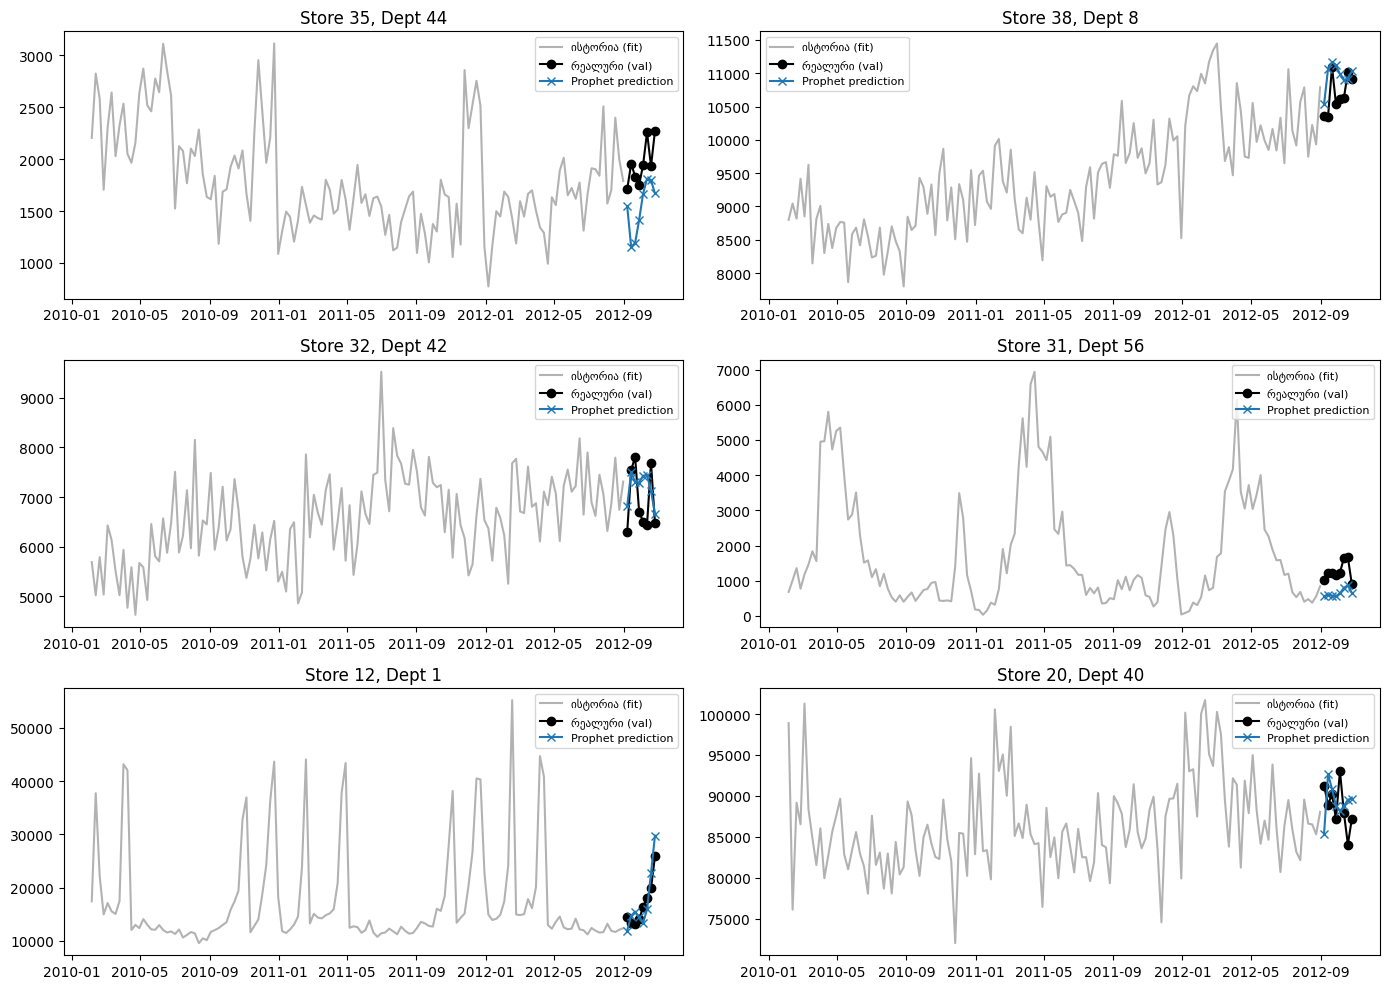

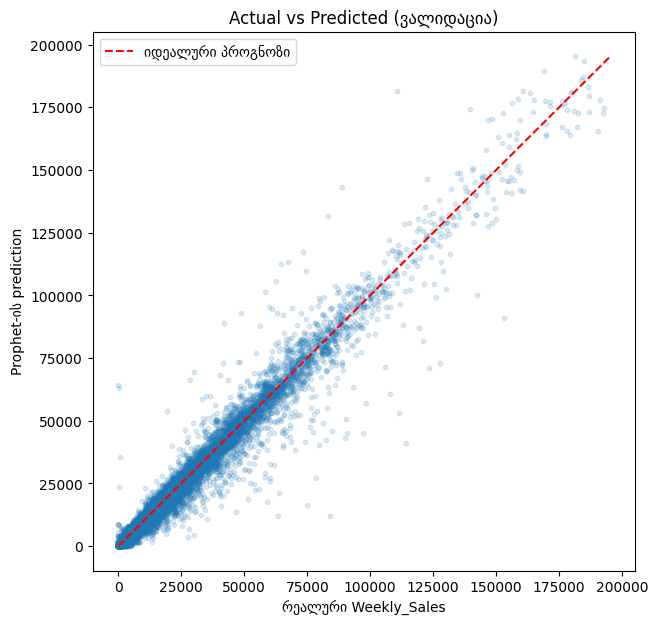

In [34]:
# 3) რამდენიმე რანდომული Store-Dept წყვილის ვიზუალიზაცია
import random
sample_pairs = random.sample(list(result[["Store", "Dept"]].drop_duplicates().itertuples(index=False)), 6)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (store, dept) in zip(axes, sample_pairs):
    hist = fit_part[(fit_part.Store == store) & (fit_part.Dept == dept)].sort_values("Date")
    actual = val_part[(val_part.Store == store) & (val_part.Dept == dept)].sort_values("Date")
    pred = result[(result.Store == store) & (result.Dept == dept)].sort_values("Date")

    ax.plot(hist["Date"], hist["Weekly_Sales"], label="ისტორია (fit)", color="gray", alpha=0.6)
    ax.plot(actual["Date"], actual["Weekly_Sales"], label="რეალური (val)", color="black", marker="o")
    ax.plot(pred["Date"], pred["Weekly_Sales_Pred"], label="Prophet prediction", color="tab:blue", marker="x")
    ax.set_title(f"Store {store}, Dept {dept}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("prophet_sample_series.png", dpi=120)
plt.show()

# 4) Overall: predicted vs actual scatter (რაც უფრო დიაგონალთან ახლოსაა, მით უკეთესია)
plt.figure(figsize=(7, 7))
plt.scatter(result["Weekly_Sales"], result["Weekly_Sales_Pred"], alpha=0.15, s=10)
max_val = max(result["Weekly_Sales"].max(), result["Weekly_Sales_Pred"].max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="იდეალური პროგნოზი")
plt.xlabel("რეალური Weekly_Sales")
plt.ylabel("Prophet-ის prediction")
plt.title("Actual vs Predicted (ვალიდაცია)")
plt.legend()
plt.savefig("prophet_scatter.png", dpi=120)
plt.show()

In [36]:
# ალტერნატიული validation window - მოიცავს 2011 Thanksgiving+Christmas-ს
cutoff_start = pd.Timestamp("2011-11-01")
cutoff_end = pd.Timestamp("2011-12-31")

fit_part_hard = train[train.Date < cutoff_start]
val_part_hard = train[(train.Date >= cutoff_start) & (train.Date <= cutoff_end)]

print("Holiday კვირების რაოდენობა (unique dates):",
      val_part_hard[val_part_hard.IsHoliday]["Date"].nunique(), "/", val_part_hard["Date"].nunique())
print("რომელი holiday თარიღებია:", sorted(val_part_hard[val_part_hard.IsHoliday]["Date"].unique()))

Holiday კვირების რაოდენობა (unique dates): 2 / 9
რომელი holiday თარიღებია: [Timestamp('2011-11-25 00:00:00'), Timestamp('2011-12-30 00:00:00')]


In [37]:
predictions_hard = []
for store, dept in tqdm(list(fit_part_hard[["Store", "Dept"]].drop_duplicates().itertuples(index=False)),
                         desc="Prophet hard-window"):
    g_train = fit_part_hard[(fit_part_hard.Store == store) & (fit_part_hard.Dept == dept)]
    g_val = val_part_hard[(val_part_hard.Store == store) & (val_part_hard.Dept == dept)]
    if g_val.empty:
        continue
    predictions_hard.append(fit_predict_one_series(g_train, g_val, holidays_df))

result_hard = pd.concat(predictions_hard, ignore_index=True)
result_hard = result_hard.merge(
    val_part_hard[["Store", "Dept", "Date", "Weekly_Sales"]],
    on=["Store", "Dept", "Date"], how="inner"
)

score_hard = wmae(result_hard["Weekly_Sales"].values, result_hard["Weekly_Sales_Pred"].values, result_hard["IsHoliday"].values)
print(f"Prophet WMAE (holiday window, Nov-Dec 2011): {score_hard:.2f}")

# შედარებისთვის naive baseline-იც იგივე ფანჯარაზე
naive_preds_hard = []
for store, dept in fit_part_hard[["Store", "Dept"]].drop_duplicates().itertuples(index=False):
    g_train = fit_part_hard[(fit_part_hard.Store == store) & (fit_part_hard.Dept == dept)].sort_values("Date")
    g_val = val_part_hard[(val_part_hard.Store == store) & (val_part_hard.Dept == dept)]
    if g_val.empty or g_train.empty:
        continue
    last_val = g_train["Weekly_Sales"].iloc[-1]
    tmp = g_val[["Store", "Dept", "Date", "IsHoliday", "Weekly_Sales"]].copy()
    tmp["Weekly_Sales_Pred"] = last_val
    naive_preds_hard.append(tmp)

naive_result_hard = pd.concat(naive_preds_hard, ignore_index=True)
naive_score_hard = wmae(naive_result_hard["Weekly_Sales"].values, naive_result_hard["Weekly_Sales_Pred"].values, naive_result_hard["IsHoliday"].values)
print(f"Naive WMAE (holiday window): {naive_score_hard:.2f}")

Streaming output truncated to the last 5000 lines.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
Prophet hard-window:  45%|████▍     | 1462/3254 [04:49<06:38,  4.50it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
Prophet hard-window:  45%|████▍     | 1463/3254 [04:49<05:36,  5.32it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
Prophet hard-window:  45%|████▍     | 1464/3254 [04:49<05:41,  5.23it/s]INFO:prophet:Disabling ye

Prophet WMAE (holiday window, Nov-Dec 2011): 5043.21
Naive WMAE (holiday window): 5180.51


In [38]:
fit_part_hard.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [50]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("Prophet-walmart")

with mlflow.start_run(run_name="prophet-baseline-holiday-window"):
    mlflow.log_param("model", "Prophet")
    mlflow.log_param("holidays", True)
    mlflow.log_param("holiday_lower_window", 0)
    mlflow.log_param("holiday_upper_window", 0)
    mlflow.log_param("regressors", "none")
    mlflow.log_param("validation_window", "2011-11-01 to 2011-12-31 (Thanksgiving+Christmas)")
    mlflow.log_param("n_holiday_dates_in_val", 2)

    mlflow.log_metric("val_wmae", score_hard)
    mlflow.log_metric("naive_wmae", naive_score_hard)
    mlflow.log_metric("improvement_over_naive_pct", 100 * (naive_score_hard - score_hard) / naive_score_hard)

print(f"დალოგინდა: WMAE={score_hard:.2f}, naive={naive_score_hard:.2f}")

🏃 View run prophet-baseline-holiday-window at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/543ff5dc933e4083b8d38b20db30bd35
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5
დალოგინდა: WMAE=5043.21, naive=5180.51


In [54]:
REGRESSORS = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "MarkDown_total"]

# def fit_predict_one_series(g_train, g_val, holidays_df=None, use_regressors=False):
#     df = g_train.rename(columns={"Date": "ds", "Weekly_Sales": "y"})
#     available_regs = [r for r in REGRESSORS if r in df.columns] if use_regressors else []
#     df = df[["ds", "y"] + available_regs].sort_values("ds")

#     if len(df) < 10:
#         fallback = g_train["Weekly_Sales"].mean() if len(g_train) else 0.0
#         out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
#         out["Weekly_Sales_Pred"] = fallback
#         return out

#     m = Prophet(holidays=holidays_df)
#     for reg in available_regs:
#         m.add_regressor(reg)
#     m.fit(df)

#     future = g_val.rename(columns={"Date": "ds"})[["ds"] + available_regs].sort_values("ds")
#     forecast = m.predict(future)

#     out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
#     out["Weekly_Sales_Pred"] = np.clip(forecast["yhat"].values, a_min=0, a_max=None)
#     return out

In [15]:
# CELL 1 - განახლებული load_data (features merge-იანი)

TRAIN_PATH = "/content/drive/MyDrive/ML final project/walmart_data/train.csv.zip"
TEST_PATH = "/content/drive/MyDrive/ML final project/walmart_data/test.csv.zip"
FEATURES_PATH = "/content/drive/MyDrive/ML final project/walmart_data/features.csv.zip"
STORES_PATH = "/content/drive/MyDrive/ML final project/walmart_data/stores.csv"

def load_data():
    train = pd.read_csv(TRAIN_PATH, parse_dates=["Date"])
    test = pd.read_csv(TEST_PATH, parse_dates=["Date"])
    features = pd.read_csv(FEATURES_PATH, parse_dates=["Date"])
    stores = pd.read_csv(STORES_PATH)

    markdown_cols = [c for c in features.columns if c.startswith("MarkDown")]
    features["MarkDown_total"] = features[markdown_cols].fillna(0).sum(axis=1) if markdown_cols else 0.0
    features = features.merge(stores, on="Store", how="left")
    features_to_merge = features.drop(columns=["IsHoliday"], errors="ignore")

    train = train.merge(features_to_merge, on=["Store", "Date"], how="left")
    test = test.merge(features_to_merge, on=["Store", "Date"], how="left")

    reg_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "MarkDown_total"]
    for df in (train, test):
        for col in reg_cols:
            if col in df.columns:
                df[col] = df[col].fillna(df[col].median())
    return train, test

In [16]:
#  - განახლებული build_holidays
def build_holidays(train):
    holiday_dates = sorted(train.loc[train["IsHoliday"] == True, "Date"].unique())
    return pd.DataFrame({
        "holiday": "walmart_holiday_week",
        "ds": pd.to_datetime(holiday_dates),
        "lower_window": -7,
        "upper_window": 3,
    })

In [61]:
#  - ყველაფრის ხელახლა გამოთვლა, ამ თანმიმდევრობით
train, test = load_data()
print("Regressors exist?", [c for c in ["Temperature","Fuel_Price","CPI","Unemployment","MarkDown_total"] if c in train.columns])

holidays_df = build_holidays(train)
print(holidays_df.iloc[0])  # lower_window უნდა იყოს -7

cutoff_start = pd.Timestamp("2011-11-01")
cutoff_end = pd.Timestamp("2011-12-31")
fit_part_hard = train[train.Date < cutoff_start]
val_part_hard = train[(train.Date >= cutoff_start) & (train.Date <= cutoff_end)]

Regressors exist? ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown_total']
holiday         walmart_holiday_week
ds               2010-02-12 00:00:00
lower_window                      -7
upper_window                       3
Name: 0, dtype: object


In [62]:
print([c for c in REGRESSORS if c in fit_part_hard.columns])  # აღარ უნდა იყოს ცარიელი
print(holidays_df.iloc[0]["lower_window"])  # -7

['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown_total']
-7


In [63]:
# 1. თავიდან გამოვთვალოთ fit_part_hard / val_part_hard ახალი train-იდან (features merged)
cutoff_start = pd.Timestamp("2011-11-01")
cutoff_end = pd.Timestamp("2011-12-31")

fit_part_hard = train[train.Date < cutoff_start]
val_part_hard = train[(train.Date >= cutoff_start) & (train.Date <= cutoff_end)]

# 2. holidays_df ხელახლა (ახალი lower/upper window-ებით)
holidays_df = build_holidays(train)

# 3. Prophet + regressors გაშვება
predictions_hard_v2 = []
for store, dept in tqdm(list(fit_part_hard[["Store", "Dept"]].drop_duplicates().itertuples(index=False)),
                         desc="Prophet + regressors, holiday window"):
    g_train = fit_part_hard[(fit_part_hard.Store == store) & (fit_part_hard.Dept == dept)]
    g_val = val_part_hard[(val_part_hard.Store == store) & (val_part_hard.Dept == dept)]
    if g_val.empty:
        continue
    predictions_hard_v2.append(fit_predict_one_series(g_train, g_val, holidays_df, use_regressors=True))

result_hard_v2 = pd.concat(predictions_hard_v2, ignore_index=True)
result_hard_v2 = result_hard_v2.merge(
    val_part_hard[["Store", "Dept", "Date", "Weekly_Sales"]],
    on=["Store", "Dept", "Date"], how="inner"
)

score_hard_v2 = wmae(result_hard_v2["Weekly_Sales"].values, result_hard_v2["Weekly_Sales_Pred"].values, result_hard_v2["IsHoliday"].values)
print(f"Prophet + wider holiday window + regressors: {score_hard_v2:.2f}")
print(f"წინა (windows=0, no regressors):              5043.21")
print(f"Naive:                                          5180.51")

Streaming output truncated to the last 5000 lines.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
Prophet + regressors, holiday window:  45%|████▍     | 1462/3254 [06:33<08:57,  3.33it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
Prophet + regressors, holiday window:  45%|████▍     | 1463/3254 [06:33<08:00,  3.73it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
Prophet + regressors, holiday window:  45%|████▍     | 1464/325

Prophet + wider holiday window + regressors: 5444.51
წინა (windows=0, no regressors):              5043.21
Naive:                                          5180.51


In [64]:
with mlflow.start_run(run_name="prophet-regressors-wide-window-holiday"):
    mlflow.log_param("model", "Prophet")
    mlflow.log_param("holidays", True)
    mlflow.log_param("holiday_lower_window", -7)
    mlflow.log_param("holiday_upper_window", 3)
    mlflow.log_param("regressors", REGRESSORS)  # Temperature, Fuel_Price, CPI, Unemployment, MarkDown_total
    mlflow.log_param("validation_window", "2011-11-01 to 2011-12-31 (Thanksgiving+Christmas)")

    mlflow.log_metric("val_wmae", score_hard_v2)
    mlflow.log_metric("naive_wmae", naive_score_hard)
    mlflow.log_metric("baseline_no_regressors_wmae", 5043.21)
    mlflow.log_metric("vs_naive_pct", 100 * (naive_score_hard - score_hard_v2) / naive_score_hard)
    mlflow.log_metric("vs_baseline_pct", 100 * (5043.21 - score_hard_v2) / 5043.21)

    result_hard_v2.to_csv("prophet_regressors_wide_window_results.csv", index=False)
    mlflow.log_artifact("prophet_regressors_wide_window_results.csv")

print(f"დალოგინდა: WMAE={score_hard_v2:.2f}")

🏃 View run prophet-regressors-wide-window-holiday at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/aedc338e6dfd4dc5b011f7e85bbe3a28
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5
დალოგინდა: WMAE=5444.51


In [17]:
def fit_predict_v2(g_train, g_val, holidays_df=None, use_regressors=False, regressor_list=None):
    reg_list = regressor_list if regressor_list is not None else REGRESSORS
    df = g_train.rename(columns={"Date": "ds", "Weekly_Sales": "y"})
    available_regs = [r for r in reg_list if r in df.columns] if use_regressors else []
    df = df[["ds", "y"] + available_regs].sort_values("ds")

    if len(df) < 10:
        fallback = g_train["Weekly_Sales"].mean() if len(g_train) else 0.0
        out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
        out["Weekly_Sales_Pred"] = fallback
        return out

    m = Prophet(holidays=holidays_df)
    for reg in available_regs:
        m.add_regressor(reg)
    m.fit(df)

    future = g_val.rename(columns={"Date": "ds"})[["ds"] + available_regs].sort_values("ds")
    forecast = m.predict(future)

    out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
    out["Weekly_Sales_Pred"] = np.clip(forecast["yhat"].values, a_min=0, a_max=None)
    return out

In [69]:
REGRESSORS_NO_MARKDOWN = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]

holidays_df_narrow = pd.DataFrame({
    "holiday": "walmart_holiday_week",
    "ds": pd.to_datetime(sorted(train.loc[train["IsHoliday"] == True, "Date"].unique())),
    "lower_window": 0,
    "upper_window": 0,
})

predictions_test = []
for store, dept in tqdm(list(fit_part_hard[["Store", "Dept"]].drop_duplicates().itertuples(index=False)),
                         desc="Prophet + regressors (no markdown), narrow window"):
    g_train = fit_part_hard[(fit_part_hard.Store == store) & (fit_part_hard.Dept == dept)]
    g_val = val_part_hard[(val_part_hard.Store == store) & (val_part_hard.Dept == dept)]
    if g_val.empty:
        continue
    predictions_test.append(fit_predict_v2(
        g_train, g_val, holidays_df_narrow, use_regressors=True, regressor_list=REGRESSORS_NO_MARKDOWN
    ))

result_test = pd.concat(predictions_test, ignore_index=True)
result_test = result_test.merge(
    val_part_hard[["Store", "Dept", "Date", "Weekly_Sales"]],
    on=["Store", "Dept", "Date"], how="inner"
)
score_test = wmae(result_test["Weekly_Sales"].values, result_test["Weekly_Sales_Pred"].values, result_test["IsHoliday"].values)
print(f"Regressors (no MarkDown) + narrow window: {score_test:.2f}")
print(f"წინა baseline (no regressors, narrow):     5043.21")
print(f"Regressors+MarkDown + wide window:         5444.51")
print(f"Naive:                                      5180.51")

Streaming output truncated to the last 5000 lines.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
Prophet + regressors (no markdown), narrow window:  45%|████▍     | 1462/3254 [04:53<05:53,  5.07it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
Prophet + regressors (no markdown), narrow window:  45%|████▍     | 1463/3254 [04:54<05:31,  5.40it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
Prophet + regressors (no markdown), n

Regressors (no MarkDown) + narrow window: 5466.87
წინა baseline (no regressors, narrow):     5043.21
Regressors+MarkDown + wide window:         5444.51
Naive:                                      5180.51


In [70]:
with mlflow.start_run(run_name="prophet-regressors-no-markdown-narrow"):
    mlflow.log_param("model", "Prophet")
    mlflow.log_param("holidays", True)
    mlflow.log_param("holiday_lower_window", 0)
    mlflow.log_param("holiday_upper_window", 0)
    mlflow.log_param("regressors", REGRESSORS_NO_MARKDOWN)
    mlflow.log_param("validation_window", "2011-11-01 to 2011-12-31")

    mlflow.log_metric("val_wmae", score_test)
    mlflow.log_metric("naive_wmae", naive_score_hard)
    mlflow.log_metric("best_so_far_wmae", 5043.21)

print(f"დალოგინდა: {score_test:.2f} — დასკვნა: regressors აზიანებს, არა აუმჯობესებს")

🏃 View run prophet-regressors-no-markdown-narrow at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/aa4a7de333f548dd9b2b715a7a88b736
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5
დალოგინდა: 5466.87 — დასკვნა: regressors აზიანებს, არა აუმჯობესებს




---



---



---



---



In [13]:
import inspect
REGRESSORS = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "MarkDown_total"]

def fit_predict_one_series(g_train, g_val, holidays_df=None, use_regressors=False, regressor_list=None,
                            changepoint_prior_scale=0.05, return_train_pred=False):
    reg_list = regressor_list if regressor_list is not None else REGRESSORS
    df = g_train.rename(columns={"Date": "ds", "Weekly_Sales": "y"})
    available_regs = [r for r in reg_list if r in df.columns] if use_regressors else []
    df = df[["ds", "y"] + available_regs].sort_values("ds")

    if len(df) < 10:
        fallback = g_train["Weekly_Sales"].mean() if len(g_train) else 0.0
        out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
        out["Weekly_Sales_Pred"] = fallback
        train_out = None
        if return_train_pred:
            train_out = g_train[["Store", "Dept", "Date"]].copy()
            train_out["Weekly_Sales_Pred"] = fallback
            train_out["Weekly_Sales"] = g_train["Weekly_Sales"].values
        return out, train_out

    m = Prophet(holidays=holidays_df, changepoint_prior_scale=changepoint_prior_scale)
    for reg in available_regs:
        m.add_regressor(reg)
    m.fit(df)

    future = g_val.rename(columns={"Date": "ds"})[["ds"] + available_regs].sort_values("ds")
    forecast = m.predict(future)
    out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
    out["Weekly_Sales_Pred"] = np.clip(forecast["yhat"].values, a_min=0, a_max=None)

    train_out = None
    if return_train_pred:
        train_forecast = m.predict(df[["ds"] + available_regs])
        train_out = g_train[["Store", "Dept", "Date"]].copy().sort_values("Date")
        train_out["Weekly_Sales"] = df["y"].values
        train_out["Weekly_Sales_Pred"] = np.clip(train_forecast["yhat"].values, a_min=0, a_max=None)

    return out, train_out

print("სწორია:", inspect.signature(fit_predict_one_series))

სწორია: (g_train, g_val, holidays_df=None, use_regressors=False, regressor_list=None, changepoint_prior_scale=0.05, return_train_pred=False)


In [19]:
import numpy as np

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

subset_keys = list(fit_part_hard[["Store", "Dept"]].drop_duplicates().itertuples(index=False))[:300]

for cps in [0.01, 0.05, 0.5]:
    val_preds, train_preds = [], []
    for store, dept in tqdm(subset_keys, desc=f"cps={cps}"):
        g_train = fit_part_hard[(fit_part_hard.Store == store) & (fit_part_hard.Dept == dept)]
        g_val = val_part_hard[(val_part_hard.Store == store) & (val_part_hard.Dept == dept)]
        if g_val.empty:
            continue
        out, train_out = fit_predict_one_series(
            g_train, g_val, holidays_df_narrow, use_regressors=False,
            changepoint_prior_scale=cps, return_train_pred=True
        )
        val_preds.append(out)
        if train_out is not None:
            train_preds.append(train_out)

    val_result = pd.concat(val_preds, ignore_index=True).merge(
        val_part_hard[["Store", "Dept", "Date", "Weekly_Sales"]], on=["Store", "Dept", "Date"], how="inner"
    )
    train_result = pd.concat(train_preds, ignore_index=True)

    val_score = wmae(val_result["Weekly_Sales"].values, val_result["Weekly_Sales_Pred"].values, val_result["IsHoliday"].values)
    train_score = mae(train_result["Weekly_Sales"].values, train_result["Weekly_Sales_Pred"].values)

    print(f"cps={cps}: val_WMAE={val_score:.2f}, train_MAE={train_score:.2f}, gap={val_score - train_score:.2f}")

cps=0.01:   0%|          | 0/300 [00:00<?, ?it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
cps=0.01:   0%|          | 1/300 [00:00<04:39,  1.07it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
cps=0.01:   1%|          | 2/300 [00:01<02:23,  2.07it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling da

cps=0.01: val_WMAE=6120.06, train_MAE=2768.24, gap=3351.82


cps=0.05:   0%|          | 0/300 [00:00<?, ?it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
cps=0.05:   0%|          | 1/300 [00:00<01:23,  3.57it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
cps=0.05:   1%|          | 2/300 [00:00<01:31,  3.26it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling da

cps=0.05: val_WMAE=6176.64, train_MAE=2742.44, gap=3434.20


cps=0.5:   0%|          | 0/300 [00:00<?, ?it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
cps=0.5:   0%|          | 1/300 [00:00<01:21,  3.67it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
cps=0.5:   1%|          | 2/300 [00:00<01:32,  3.21it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily

cps=0.5: val_WMAE=6795.94, train_MAE=2237.62, gap=4558.32


In [22]:
"""
Prophet BASELINE - Walmart Store Sales Forecasting
------------------------------------------------------
უმარტივესი ვერსია: თითო (Store, Dept) წყვილზე default Prophet,
არანაირი გარე regressor, არანაირი holiday-ლოგიკა.
მხოლოდ ისტორიული Weekly_Sales -> yhat prediction.

შემდეგ ეტაპზე დავამატებთ: holidays, regressors, MLflow logging.
"""

import warnings
import logging
import numpy as np
import pandas as pd
from prophet import Prophet
from tqdm import tqdm

warnings.filterwarnings("ignore")
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

DATA_DIR = "./data"
TRAIN_PATH = f"{DATA_DIR}/train.csv"
TEST_PATH = f"{DATA_DIR}/test.csv"
FEATURES_PATH = f"{DATA_DIR}/features.csv"
STORES_PATH = f"{DATA_DIR}/stores.csv"


def load_data():
    train = pd.read_csv(TRAIN_PATH, parse_dates=["Date"])
    test = pd.read_csv(TEST_PATH, parse_dates=["Date"])
    features = pd.read_csv(FEATURES_PATH, parse_dates=["Date"])
    stores = pd.read_csv(STORES_PATH)

    markdown_cols = [c for c in features.columns if c.startswith("MarkDown")]
    features["MarkDown_total"] = features[markdown_cols].fillna(0).sum(axis=1) if markdown_cols else 0.0

    features = features.merge(stores, on="Store", how="left")

    # IsHoliday უკვე არსებობს train/test-ში, features-იდან არ გვჭირდება დუბლირება
    features_to_merge = features.drop(columns=["IsHoliday"], errors="ignore")

    train = train.merge(features_to_merge, on=["Store", "Date"], how="left")
    test = test.merge(features_to_merge, on=["Store", "Date"], how="left")

    reg_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "MarkDown_total"]
    for df in (train, test):
        for col in reg_cols:
            if col in df.columns:
                df[col] = df[col].fillna(df[col].median())

    return train, test


def build_holidays(train: pd.DataFrame) -> pd.DataFrame:
    """
    IsHoliday=True მქონე თარიღები Prophet-ის holiday ფორმატში.
    lower_window/upper_window: Thanksgiving/Christmas-ის shopping ეფექტი
    ერთ დღეზე ადრე იწყება და კვირით გრძელდება, ამიტომ ფანჯარას ვაფართოებთ.
    """
    holiday_dates = sorted(train.loc[train["IsHoliday"] == True, "Date"].unique())
    return pd.DataFrame({
        "holiday": "walmart_holiday_week",
        "ds": pd.to_datetime(holiday_dates),
        "lower_window": -7,  # კვირით ადრე იწყება ეფექტი
        "upper_window": 3,   # და კიდევ რამდენიმე დღე გრძელდება
    })


REGRESSORS = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "MarkDown_total"]


def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))


def fit_predict_one_series(g_train: pd.DataFrame, g_val: pd.DataFrame, holidays_df: pd.DataFrame = None,
                            use_regressors: bool = False, regressor_list: list = None,
                            changepoint_prior_scale: float = 0.05, return_train_pred: bool = False):
    reg_list = regressor_list if regressor_list is not None else REGRESSORS
    df = g_train.rename(columns={"Date": "ds", "Weekly_Sales": "y"})
    available_regs = [r for r in reg_list if r in df.columns] if use_regressors else []
    df = df[["ds", "y"] + available_regs].sort_values("ds")

    if len(df) < 10:
        fallback = g_train["Weekly_Sales"].mean() if len(g_train) else 0.0
        out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
        out["Weekly_Sales_Pred"] = fallback
        train_out = None
        if return_train_pred:
            train_out = g_train[["Store", "Dept", "Date", "IsHoliday"]].copy()
            train_out["Weekly_Sales_Pred"] = fallback
            train_out["Weekly_Sales"] = g_train["Weekly_Sales"].values
        return out, train_out

    m = Prophet(holidays=holidays_df, changepoint_prior_scale=changepoint_prior_scale)
    for reg in available_regs:
        m.add_regressor(reg)
    m.fit(df)

    future = g_val.rename(columns={"Date": "ds"})[["ds"] + available_regs].sort_values("ds")
    forecast = m.predict(future)

    out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
    out["Weekly_Sales_Pred"] = np.clip(forecast["yhat"].values, a_min=0, a_max=None)

    train_out = None
    if return_train_pred:
        train_forecast = m.predict(df[["ds"] + available_regs])
        train_out = g_train[["Store", "Dept", "Date", "IsHoliday"]].copy().sort_values("Date")
        train_out["Weekly_Sales"] = df["y"].values
        train_out["Weekly_Sales_Pred"] = np.clip(train_forecast["yhat"].values, a_min=0, a_max=None)

    return out, train_out


In [23]:
results_table = []

for cps in [0.01, 0.05, 0.5]:
    val_preds, train_preds = [], []
    for store, dept in tqdm(subset_keys, desc=f"cps={cps}"):
        g_train = fit_part_hard[(fit_part_hard.Store == store) & (fit_part_hard.Dept == dept)]
        g_val = val_part_hard[(val_part_hard.Store == store) & (val_part_hard.Dept == dept)]
        if g_val.empty:
            continue
        out, train_out = fit_predict_one_series(
            g_train, g_val, holidays_df_narrow, use_regressors=False,
            changepoint_prior_scale=cps, return_train_pred=True
        )
        val_preds.append(out)
        if train_out is not None:
            train_preds.append(train_out)

    val_result = pd.concat(val_preds, ignore_index=True).merge(
        val_part_hard[["Store", "Dept", "Date", "Weekly_Sales"]], on=["Store", "Dept", "Date"], how="inner"
    )
    train_result = pd.concat(train_preds, ignore_index=True)

    val_score = wmae(val_result["Weekly_Sales"].values, val_result["Weekly_Sales_Pred"].values, val_result["IsHoliday"].values)
    train_score = wmae(train_result["Weekly_Sales"].values, train_result["Weekly_Sales_Pred"].values, train_result["IsHoliday"].values)  # <- აქ იყო cვლილება: mae -> wmae
    gap = val_score - train_score

    results_table.append({"changepoint_prior_scale": cps, "val_wmae": val_score, "train_wmae": train_score, "gap": gap})

results_df = pd.DataFrame(results_table)
print(results_df)

cps=0.5: 100%|██████████| 300/300 [01:39<00:00,  3.02it/s]

   changepoint_prior_scale     val_wmae   train_wmae          gap
0                     0.01  6120.060545  3045.452519  3074.608026
1                     0.05  6176.643839  3014.690711  3161.953128
2                     0.50  6795.941993  2505.692379  4290.249614


In [24]:
predictions_cps001, train_preds_cps001 = [], []
for store, dept in tqdm(list(fit_part_hard[["Store", "Dept"]].drop_duplicates().itertuples(index=False)),
                         desc="Prophet cps=0.01 FULL"):
    g_train = fit_part_hard[(fit_part_hard.Store == store) & (fit_part_hard.Dept == dept)]
    g_val = val_part_hard[(val_part_hard.Store == store) & (val_part_hard.Dept == dept)]
    if g_val.empty:
        continue
    out, train_out = fit_predict_one_series(
        g_train, g_val, holidays_df_narrow, use_regressors=False,
        changepoint_prior_scale=0.01, return_train_pred=True
    )
    predictions_cps001.append(out)
    if train_out is not None:
        train_preds_cps001.append(train_out)

val_result_full = pd.concat(predictions_cps001, ignore_index=True).merge(
    val_part_hard[["Store", "Dept", "Date", "Weekly_Sales"]], on=["Store", "Dept", "Date"], how="inner"
)
train_result_full = pd.concat(train_preds_cps001, ignore_index=True)

val_score_full = wmae(val_result_full["Weekly_Sales"].values, val_result_full["Weekly_Sales_Pred"].values, val_result_full["IsHoliday"].values)
train_score_full = wmae(train_result_full["Weekly_Sales"].values, train_result_full["Weekly_Sales_Pred"].values, train_result_full["IsHoliday"].values)

print(f"cps=0.01 FULL (3254 series):")
print(f"  val_WMAE   = {val_score_full:.2f}")
print(f"  train_WMAE = {train_score_full:.2f}")
print(f"  gap        = {val_score_full - train_score_full:.2f}")
print(f"წინა baseline (cps=0.05 default, narrow window): 5043.21")

with mlflow.start_run(run_name="prophet-cps-0.01-FULL"):
    mlflow.log_param("model", "Prophet")
    mlflow.log_param("changepoint_prior_scale", 0.01)
    mlflow.log_param("holidays", "narrow_window")
    mlflow.log_param("regressors", "none")
    mlflow.log_param("validation_window", "2011-11-01 to 2011-12-31")
    mlflow.log_metric("val_wmae", val_score_full)
    mlflow.log_metric("train_wmae", train_score_full)
    mlflow.log_metric("train_val_gap", val_score_full - train_score_full)

Prophet cps=0.01 FULL: 100%|██████████| 3254/3254 [09:06<00:00,  5.96it/s]


cps=0.01 FULL (3254 series):
  val_WMAE   = 5003.30
  train_WMAE = 2621.46
  gap        = 2381.83
წინა baseline (cps=0.05 default, narrow window): 5043.21
🏃 View run prophet-cps-0.01-FULL at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/b621650e6e9b405bbd50ecee1e50a5c4
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5


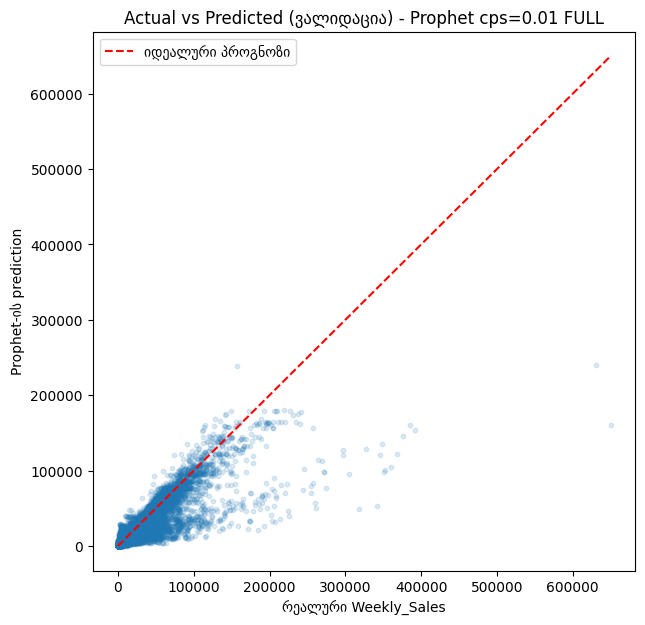

In [25]:
import matplotlib.pyplot as plt

# Overall: predicted vs actual scatter for the full Prophet cps=0.01 model
plt.figure(figsize=(7, 7))
plt.scatter(val_result_full["Weekly_Sales"], val_result_full["Weekly_Sales_Pred"], alpha=0.15, s=10)
max_val = max(val_result_full["Weekly_Sales"].max(), val_result_full["Weekly_Sales_Pred"].max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="იდეალური პროგნოზი")
plt.xlabel("რეალური Weekly_Sales")
plt.ylabel("Prophet-ის prediction")
plt.title("Actual vs Predicted (ვალიდაცია) - Prophet cps=0.01 FULL")
plt.legend()
plt.savefig("prophet_cps001_full_scatter.png", dpi=120)
plt.show()

In [31]:
"""
Prophet BASELINE - Walmart Store Sales Forecasting
------------------------------------------------------
უმარტივესი ვერსია: თითო (Store, Dept) წყვილზე default Prophet,
არანაირი გარე regressor, არანაირი holiday-ლოგიკა.
მხოლოდ ისტორიული Weekly_Sales -> yhat prediction.

შემდეგ ეტაპზე დავამატებთ: holidays, regressors, MLflow logging.
"""

import warnings
import logging
import numpy as np
import pandas as pd
from prophet import Prophet
from tqdm import tqdm

warnings.filterwarnings("ignore")
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

TRAIN_PATH = "/content/drive/MyDrive/ML final project/walmart_data/train.csv.zip"
TEST_PATH = "/content/drive/MyDrive/ML final project/walmart_data/test.csv.zip"
FEATURES_PATH = "/content/drive/MyDrive/ML final project/walmart_data/features.csv.zip"
STORES_PATH = "/content/drive/MyDrive/ML final project/walmart_data/stores.csv"

def load_data():
    train = pd.read_csv(TRAIN_PATH, parse_dates=["Date"])
    test = pd.read_csv(TEST_PATH, parse_dates=["Date"])
    features = pd.read_csv(FEATURES_PATH, parse_dates=["Date"])
    stores = pd.read_csv(STORES_PATH)

    markdown_cols = [c for c in features.columns if c.startswith("MarkDown")]
    features["MarkDown_total"] = features[markdown_cols].fillna(0).sum(axis=1) if markdown_cols else 0.0

    features = features.merge(stores, on="Store", how="left")

    # IsHoliday უკვე არსებობს train/test-ში, features-იდან არ გვჭირდება დუბლირება
    features_to_merge = features.drop(columns=["IsHoliday"], errors="ignore")

    train = train.merge(features_to_merge, on=["Store", "Date"], how="left")
    test = test.merge(features_to_merge, on=["Store", "Date"], how="left")

    reg_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "MarkDown_total"]
    for df in (train, test):
        for col in reg_cols:
            if col in df.columns:
                df[col] = df[col].fillna(df[col].median())

    return train, test


def build_holidays(train: pd.DataFrame) -> pd.DataFrame:
    """
    IsHoliday=True მქონე თარიღები Prophet-ის holiday ფორმატში.
    lower_window/upper_window: Thanksgiving/Christmas-ის shopping ეფექტი
    ერთ დღეზე ადრე იწყება და კვირით გრძელდება, ამიტომ ფანჯარას ვაფართოებთ.
    """
    holiday_dates = sorted(train.loc[train["IsHoliday"] == True, "Date"].unique())
    return pd.DataFrame({
        "holiday": "walmart_holiday_week",
        "ds": pd.to_datetime(holiday_dates),
        "lower_window": -7,  # კვირით ადრე იწყება ეფექტი
        "upper_window": 3,   # და კიდევ რამდენიმე დღე გრძელდება
    })


REGRESSORS = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "MarkDown_total"]


def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))


def fit_predict_one_series(g_train: pd.DataFrame, g_val: pd.DataFrame, holidays_df: pd.DataFrame = None,
                            use_regressors: bool = False, regressor_list: list = None,
                            changepoint_prior_scale: float = 0.05, return_train_pred: bool = False,
                            seasonality_mode: str = "additive"):
    reg_list = regressor_list if regressor_list is not None else REGRESSORS
    df = g_train.rename(columns={"Date": "ds", "Weekly_Sales": "y"})
    available_regs = [r for r in reg_list if r in df.columns] if use_regressors else []
    df = df[["ds", "y"] + available_regs].sort_values("ds")

    if len(df) < 10:
        fallback = g_train["Weekly_Sales"].mean() if len(g_train) else 0.0
        out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
        out["Weekly_Sales_Pred"] = fallback
        train_out = None
        if return_train_pred:
            train_out = g_train[["Store", "Dept", "Date", "IsHoliday"]].copy()
            train_out["Weekly_Sales_Pred"] = fallback
            train_out["Weekly_Sales"] = g_train["Weekly_Sales"].values
        return out, train_out

    m = Prophet(holidays=holidays_df, changepoint_prior_scale=changepoint_prior_scale,
                seasonality_mode=seasonality_mode)
    for reg in available_regs:
        m.add_regressor(reg)
    m.fit(df)

    future = g_val.rename(columns={"Date": "ds"})[["ds"] + available_regs].sort_values("ds")
    forecast = m.predict(future)

    out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
    out["Weekly_Sales_Pred"] = np.clip(forecast["yhat"].values, a_min=0, a_max=None)

    train_out = None
    if return_train_pred:
        train_forecast = m.predict(df[["ds"] + available_regs])
        train_out = g_train[["Store", "Dept", "Date", "IsHoliday"]].copy().sort_values("Date")
        train_out["Weekly_Sales"] = df["y"].values
        train_out["Weekly_Sales_Pred"] = np.clip(train_forecast["yhat"].values, a_min=0, a_max=None)

    return out, train_out


# NOTE: ეს ფაილი reference-ისთვისაა (ფუნქციების განმარტება).
# ფაქტობრივი ექსპერიმენტები notebook-ში მიმდინარეობს, hard validation window-ით
# (2011-11-01 – 2011-12-31), იხ. PROPHET_README.md ყველა ცდის ისტორიისთვის.
# ძველი main()/easy-window ლოგიკა აქედან წაშლილია, რომ აღარასდროს შემთხვევით არ გაეშვას.

In [32]:
predictions_mult, train_preds_mult = [], []
for store, dept in tqdm(list(fit_part_hard[["Store", "Dept"]].drop_duplicates().itertuples(index=False)),
                         desc="Prophet cps=0.01 multiplicative FULL"):
    g_train = fit_part_hard[(fit_part_hard.Store == store) & (fit_part_hard.Dept == dept)]
    g_val = val_part_hard[(val_part_hard.Store == store) & (val_part_hard.Dept == dept)]
    if g_val.empty:
        continue
    out, train_out = fit_predict_one_series(
        g_train, g_val, holidays_df_narrow, use_regressors=False,
        changepoint_prior_scale=0.01, return_train_pred=True,
        seasonality_mode="multiplicative"
    )
    predictions_mult.append(out)
    if train_out is not None:
        train_preds_mult.append(train_out)

val_result_mult = pd.concat(predictions_mult, ignore_index=True).merge(
    val_part_hard[["Store", "Dept", "Date", "Weekly_Sales"]], on=["Store", "Dept", "Date"], how="inner"
)
train_result_mult = pd.concat(train_preds_mult, ignore_index=True)

val_score_mult = wmae(val_result_mult["Weekly_Sales"].values, val_result_mult["Weekly_Sales_Pred"].values, val_result_mult["IsHoliday"].values)
train_score_mult = wmae(train_result_mult["Weekly_Sales"].values, train_result_mult["Weekly_Sales_Pred"].values, train_result_mult["IsHoliday"].values)

print(f"cps=0.01, multiplicative FULL:")
print(f"  val_WMAE   = {val_score_mult:.2f}")
print(f"  train_WMAE = {train_score_mult:.2f}")
print(f"  gap        = {val_score_mult - train_score_mult:.2f}")
print(f"წინა საუკეთესო (cps=0.01, additive): 5003.30")

with mlflow.start_run(run_name="prophet-cps-0.01-multiplicative-FULL"):
    mlflow.log_param("model", "Prophet")
    mlflow.log_param("changepoint_prior_scale", 0.01)
    mlflow.log_param("seasonality_mode", "multiplicative")
    mlflow.log_param("holidays", "narrow_window")
    mlflow.log_param("regressors", "none")
    mlflow.log_param("validation_window", "2011-11-01 to 2011-12-31")
    mlflow.log_metric("val_wmae", val_score_mult)
    mlflow.log_metric("train_wmae", train_score_mult)
    mlflow.log_metric("train_val_gap", val_score_mult - train_score_mult)

Prophet cps=0.01 multiplicative FULL: 100%|██████████| 3254/3254 [09:24<00:00,  5.76it/s]


cps=0.01, multiplicative FULL:
  val_WMAE   = 5037.35
  train_WMAE = 2618.49
  gap        = 2418.86
წინა საუკეთესო (cps=0.01, additive): 5003.30
🏃 View run prophet-cps-0.01-multiplicative-FULL at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/debea50167f24791a2e34e98676b0817
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5


In [34]:
"""
Prophet BASELINE - Walmart Store Sales Forecasting
------------------------------------------------------
უმარტივესი ვერსია: თითო (Store, Dept) წყვილზე default Prophet,
არანაირი გარე regressor, არანაირი holiday-ლოგიკა.
მხოლოდ ისტორიული Weekly_Sales -> yhat prediction.

შემდეგ ეტაპზე დავამატებთ: holidays, regressors, MLflow logging.
"""

import warnings
import logging
import numpy as np
import pandas as pd
from prophet import Prophet
from tqdm import tqdm

warnings.filterwarnings("ignore")
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

TRAIN_PATH = "/content/drive/MyDrive/ML final project/walmart_data/train.csv.zip"
TEST_PATH = "/content/drive/MyDrive/ML final project/walmart_data/test.csv.zip"
FEATURES_PATH = "/content/drive/MyDrive/ML final project/walmart_data/features.csv.zip"
STORES_PATH = "/content/drive/MyDrive/ML final project/walmart_data/stores.csv"

def load_data():
    train = pd.read_csv(TRAIN_PATH, parse_dates=["Date"])
    test = pd.read_csv(TEST_PATH, parse_dates=["Date"])
    features = pd.read_csv(FEATURES_PATH, parse_dates=["Date"])
    stores = pd.read_csv(STORES_PATH)

    markdown_cols = [c for c in features.columns if c.startswith("MarkDown")]
    features["MarkDown_total"] = features[markdown_cols].fillna(0).sum(axis=1) if markdown_cols else 0.0

    features = features.merge(stores, on="Store", how="left")

    # IsHoliday უკვე არსებობს train/test-ში, features-იდან არ გვჭირდება დუბლირება
    features_to_merge = features.drop(columns=["IsHoliday"], errors="ignore")

    train = train.merge(features_to_merge, on=["Store", "Date"], how="left")
    test = test.merge(features_to_merge, on=["Store", "Date"], how="left")

    reg_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "MarkDown_total"]
    for df in (train, test):
        for col in reg_cols:
            if col in df.columns:
                df[col] = df[col].fillna(df[col].median())

    return train, test


def build_holidays(train: pd.DataFrame) -> pd.DataFrame:
    """
    IsHoliday=True მქონე თარიღები Prophet-ის holiday ფორმატში.
    lower_window/upper_window: Thanksgiving/Christmas-ის shopping ეფექტი
    ერთ დღეზე ადრე იწყება და კვირით გრძელდება, ამიტომ ფანჯარას ვაფართოებთ.
    """
    holiday_dates = sorted(train.loc[train["IsHoliday"] == True, "Date"].unique())
    return pd.DataFrame({
        "holiday": "walmart_holiday_week",
        "ds": pd.to_datetime(holiday_dates),
        "lower_window": -7,  # კვირით ადრე იწყება ეფექტი
        "upper_window": 3,   # და კიდევ რამდენიმე დღე გრძელდება
    })


REGRESSORS = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "MarkDown_total"]


def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))


def fit_predict_one_series(g_train: pd.DataFrame, g_val: pd.DataFrame, holidays_df: pd.DataFrame = None,
                            use_regressors: bool = False, regressor_list: list = None,
                            changepoint_prior_scale: float = 0.05, return_train_pred: bool = False,
                            seasonality_mode: str = "additive", holidays_prior_scale: float = 10.0):
    reg_list = regressor_list if regressor_list is not None else REGRESSORS
    df = g_train.rename(columns={"Date": "ds", "Weekly_Sales": "y"})
    available_regs = [r for r in reg_list if r in df.columns] if use_regressors else []
    df = df[["ds", "y"] + available_regs].sort_values("ds")

    if len(df) < 10:
        fallback = g_train["Weekly_Sales"].mean() if len(g_train) else 0.0
        out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
        out["Weekly_Sales_Pred"] = fallback
        train_out = None
        if return_train_pred:
            train_out = g_train[["Store", "Dept", "Date", "IsHoliday"]].copy()
            train_out["Weekly_Sales_Pred"] = fallback
            train_out["Weekly_Sales"] = g_train["Weekly_Sales"].values
        return out, train_out

    m = Prophet(holidays=holidays_df, changepoint_prior_scale=changepoint_prior_scale,
                seasonality_mode=seasonality_mode, holidays_prior_scale=holidays_prior_scale)
    for reg in available_regs:
        m.add_regressor(reg)
    m.fit(df)

    future = g_val.rename(columns={"Date": "ds"})[["ds"] + available_regs].sort_values("ds")
    forecast = m.predict(future)

    out = g_val[["Store", "Dept", "Date", "IsHoliday"]].copy()
    out["Weekly_Sales_Pred"] = np.clip(forecast["yhat"].values, a_min=0, a_max=None)

    train_out = None
    if return_train_pred:
        train_forecast = m.predict(df[["ds"] + available_regs])
        train_out = g_train[["Store", "Dept", "Date", "IsHoliday"]].copy().sort_values("Date")
        train_out["Weekly_Sales"] = df["y"].values
        train_out["Weekly_Sales_Pred"] = np.clip(train_forecast["yhat"].values, a_min=0, a_max=None)

    return out, train_out


# NOTE: ეს ფაილი reference-ისთვისაა (ფუნქციების განმარტება).
# ფაქტობრივი ექსპერიმენტები notebook-ში მიმდინარეობს, hard validation window-ით
# (2011-11-01 – 2011-12-31), იხ. PROPHET_README.md ყველა ცდის ისტორიისთვის.
# ძველი main()/easy-window ლოგიკა აქედან წაშლილია, რომ აღარასდროს შემთხვევით არ გაეშვას.

In [35]:
results_hps = []

for hps in [0.1, 1.0, 10.0, 30.0]:
    val_preds, train_preds = [], []
    for store, dept in tqdm(subset_keys, desc=f"hps={hps}"):
        g_train = fit_part_hard[(fit_part_hard.Store == store) & (fit_part_hard.Dept == dept)]
        g_val = val_part_hard[(val_part_hard.Store == store) & (val_part_hard.Dept == dept)]
        if g_val.empty:
            continue
        out, train_out = fit_predict_one_series(
            g_train, g_val, holidays_df_narrow, use_regressors=False,
            changepoint_prior_scale=0.01, return_train_pred=True,
            seasonality_mode="additive", holidays_prior_scale=hps
        )
        val_preds.append(out)
        if train_out is not None:
            train_preds.append(train_out)

    val_result = pd.concat(val_preds, ignore_index=True).merge(
        val_part_hard[["Store", "Dept", "Date", "Weekly_Sales"]], on=["Store", "Dept", "Date"], how="inner"
    )
    train_result = pd.concat(train_preds, ignore_index=True)

    val_score = wmae(val_result["Weekly_Sales"].values, val_result["Weekly_Sales_Pred"].values, val_result["IsHoliday"].values)
    train_score = wmae(train_result["Weekly_Sales"].values, train_result["Weekly_Sales_Pred"].values, train_result["IsHoliday"].values)
    gap = val_score - train_score

    results_hps.append({"holidays_prior_scale": hps, "val_wmae": val_score, "train_wmae": train_score, "gap": gap})

results_hps_df = pd.DataFrame(results_hps)
print(results_hps_df)

hps=30.0: 100%|██████████| 300/300 [00:53<00:00,  5.60it/s]


   holidays_prior_scale     val_wmae   train_wmae          gap
0                   0.1  6216.027062  3039.757938  3176.269124
1                   1.0  6123.938691  3044.958296  3078.980395
2                  10.0  6120.060545  3045.452519  3074.608026
3                  30.0  6119.604923  3045.367071  3074.237851


In [37]:
hps_results = [
    {"hps": 0.1,  "val_wmae": 6216.027062, "train_wmae": 3039.757938, "gap": 3176.269124},
    {"hps": 1.0,  "val_wmae": 6123.938691, "train_wmae": 3044.958296, "gap": 3078.980395},
    {"hps": 10.0, "val_wmae": 6120.060545, "train_wmae": 3045.452519, "gap": 3074.608026},
    {"hps": 30.0, "val_wmae": 6119.604923, "train_wmae": 3045.367071, "gap": 3074.237851},
]

for r in hps_results:
    with mlflow.start_run(run_name=f"prophet-hps-{r['hps']}-subset300"):
        mlflow.log_param("model", "Prophet")
        mlflow.log_param("changepoint_prior_scale", 0.01)
        mlflow.log_param("holidays_prior_scale", r["hps"])
        mlflow.log_param("seasonality_mode", "additive")
        mlflow.log_param("holidays", "narrow_window")
        mlflow.log_param("regressors", "none")
        mlflow.log_param("subset_size", 300)
        mlflow.log_param("validation_window", "2011-11-01 to 2011-12-31")

        mlflow.log_metric("val_wmae", r["val_wmae"])
        mlflow.log_metric("train_wmae", r["train_wmae"])
        mlflow.log_metric("train_val_gap", r["gap"])

print("4 ცალკეული run დალოგინდა holidays_prior_scale-ისთვის.")

🏃 View run prophet-hps-0.1-subset300 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/f9c583deb41a4cb3afbbd3f330b2c2e3
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5
🏃 View run prophet-hps-1.0-subset300 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/39cd1609c8df4ea3a5a47f9fbe85a3fa
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5
🏃 View run prophet-hps-10.0-subset300 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/77faa87812174f1ea1f937572d9883bb
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5
🏃 View run prophet-hps-30.0-subset300 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/6f8e61c142aa4235afc14f6c0322656f
🧪 View experiment at: https:

In [42]:
"""
Prophet Per-Series Pipeline - Walmart Store Sales Forecasting
----------------------------------------------------------------
XGBoost-ის sklearn Pipeline-ის მსგავსი "ერთი ობიექტი", რომელიც
3254 ცალკეულ Prophet მოდელს (თითო Store-Dept წყვილზე) ინახავს
ერთ picklable/loadable ერთეულად.

გამოყენება:
    forecaster = ProphetPerSeriesForecaster(
        holidays_df=holidays_df_narrow,
        changepoint_prior_scale=0.01,
        seasonality_mode="additive",
    )
    forecaster.fit(train_df)                      # ვწვრთნით ყველა სერიას
    preds = forecaster.predict(test_df)            # ვაკეთებთ prediction-ს

MLflow-ზე შენახვა/ჩატვირთვა:
    log_forecaster(forecaster, artifact_path="model")
    loaded = load_forecaster(model_uri)             # inference-ისთვის
"""

import numpy as np
import pandas as pd
from prophet import Prophet
import mlflow
import mlflow.pyfunc


REGRESSORS = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "MarkDown_total"]


class ProphetPerSeriesForecaster:
    """თითო (Store, Dept) წყვილზე ცალკე Prophet მოდელი. sklearn-style fit/predict."""

    def __init__(self, holidays_df=None, changepoint_prior_scale=0.01,
                 seasonality_mode="additive", holidays_prior_scale=10.0,
                 use_regressors=False, regressor_list=None, min_obs=10):
        self.holidays_df = holidays_df
        self.changepoint_prior_scale = changepoint_prior_scale
        self.seasonality_mode = seasonality_mode
        self.holidays_prior_scale = holidays_prior_scale
        self.use_regressors = use_regressors
        self.regressor_list = regressor_list or REGRESSORS
        self.min_obs = min_obs

        self.models_ = {}       # (store, dept) -> fitted Prophet model
        self.fallbacks_ = {}    # (store, dept) -> fallback mean, თუ სერია ძალიან მოკლეა

    def fit(self, train_df: pd.DataFrame, verbose=True):
        keys = train_df[["Store", "Dept"]].drop_duplicates().itertuples(index=False)
        keys = list(keys)

        iterator = keys
        if verbose:
            from tqdm import tqdm
            iterator = tqdm(keys, desc="Fitting Prophet per Store-Dept")

        for store, dept in iterator:
            g = train_df[(train_df.Store == store) & (train_df.Dept == dept)]
            df = g.rename(columns={"Date": "ds", "Weekly_Sales": "y"})
            available_regs = [r for r in self.regressor_list if r in df.columns] if self.use_regressors else []
            df = df[["ds", "y"] + available_regs].sort_values("ds")

            if len(df) < self.min_obs:
                self.fallbacks_[(store, dept)] = g["Weekly_Sales"].mean() if len(g) else 0.0
                continue

            m = Prophet(
                holidays=self.holidays_df,
                changepoint_prior_scale=self.changepoint_prior_scale,
                seasonality_mode=self.seasonality_mode,
                holidays_prior_scale=self.holidays_prior_scale,
            )
            for reg in available_regs:
                m.add_regressor(reg)
            m.fit(df)
            self.models_[(store, dept)] = m

        return self

    def predict(self, future_df: pd.DataFrame) -> pd.DataFrame:
        """
        future_df: Store, Dept, Date სვეტები (+ regressor სვეტები, თუ use_regressors=True)
        აბრუნებს: Store, Dept, Date, Weekly_Sales_Pred
        """
        results = []
        keys = future_df[["Store", "Dept"]].drop_duplicates().itertuples(index=False)

        for store, dept in keys:
            g = future_df[(future_df.Store == store) & (future_df.Dept == dept)]

            if (store, dept) in self.models_:
                m = self.models_[(store, dept)]
                available_regs = [r for r in self.regressor_list if r in g.columns] if self.use_regressors else []
                fut = g.rename(columns={"Date": "ds"})[["ds"] + available_regs].sort_values("ds")
                forecast = m.predict(fut)
                out = g[["Store", "Dept", "Date"]].copy()
                out["Weekly_Sales_Pred"] = np.clip(forecast["yhat"].values, a_min=0, a_max=None)
            else:
                # ან fallback (მოკლე სერია), ან სულ ახალი, ტრენინგში არნახული (Store, Dept)
                fallback = self.fallbacks_.get((store, dept), 0.0)
                out = g[["Store", "Dept", "Date"]].copy()
                out["Weekly_Sales_Pred"] = fallback

            results.append(out)

        return pd.concat(results, ignore_index=True)


# ---------------------------------------------------------------------------
# MLflow pyfunc wrapper - შენახვა/ჩატვირთვა
# ---------------------------------------------------------------------------

class _ProphetPyfuncWrapper(mlflow.pyfunc.PythonModel):
    """მცირე wrapper, რომ ProphetPerSeriesForecaster mlflow.pyfunc-ს მიესადაგოს."""

    def load_context(self, context):
        import cloudpickle
        with open(context.artifacts["forecaster"], "rb") as f:
            self.forecaster = cloudpickle.load(f)

    def predict(self, context, model_input: pd.DataFrame) -> pd.DataFrame:
        return self.forecaster.predict(model_input)


def log_forecaster(forecaster: ProphetPerSeriesForecaster, artifact_path: str = "model",
                    registered_model_name: str = None):
    """
    ინახავს მთელ forecaster-ს (ყველა 3254 fitted Prophet მოდელს) ერთ MLflow model artifact-ად,
    cloudpickle serialization-ით (skops-ის თავიდან ასაცილებლად, radgan Prophet custom class-ია).
    """
    import cloudpickle
    import tempfile
    import os

    with tempfile.TemporaryDirectory() as tmp_dir:
        pkl_path = os.path.join(tmp_dir, "forecaster.pkl")
        with open(pkl_path, "wb") as f:
            cloudpickle.dump(forecaster, f)

        mlflow.pyfunc.log_model(
            artifact_path=artifact_path,
            python_model=_ProphetPyfuncWrapper(),
            artifacts={"forecaster": pkl_path},
            registered_model_name=registered_model_name,
        )
    print(f"Forecaster დალოგინდა MLflow-ზე, artifact_path='{artifact_path}'")


def load_forecaster(model_uri: str):
    """
    ჩატვირთვა inference-ისთვის, მაგ:
        model_uri = f"runs:/{run_id}/model"
        # ან: model_uri = "models:/ProphetWalmartForecaster/Production"
    """
    loaded_model = mlflow.pyfunc.load_model(model_uri)
    return loaded_model  # loaded_model.predict(future_df) გამოსაძახებლად მზადაა

In [44]:
# from prophet_pipeline import ProphetPerSeriesForecaster, log_forecaster, load_forecaster

# ჩვენი საუკეთესო კონფიგი
forecaster = ProphetPerSeriesForecaster(
    holidays_df=holidays_df_narrow,
    changepoint_prior_scale=0.01,
    seasonality_mode="additive",
    holidays_prior_scale=10.0,
    use_regressors=False,
)

with mlflow.start_run(run_name="prophet-final-pipeline"):
    mlflow.log_param("changepoint_prior_scale", 0.01)
    mlflow.log_param("seasonality_mode", "additive")
    mlflow.log_param("holidays_prior_scale", 10.0)

    forecaster.fit(fit_part_hard)  # ან სრულ train-ზეც, საბოლოო submission-ისთვის

    val_preds = forecaster.predict(val_part_hard[["Store", "Dept", "Date"]])
    val_eval = val_preds.merge(val_part_hard[["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"]],
                                on=["Store", "Dept", "Date"])
    score = wmae(val_eval["Weekly_Sales"].values, val_eval["Weekly_Sales_Pred"].values, val_eval["IsHoliday"].values)
    mlflow.log_metric("val_wmae", score)
    print(f"val_WMAE: {score:.2f}")

    log_forecaster(forecaster, artifact_path="model")  # ⬅️ ეს ინახავს მთელ pipeline-ს

Fitting Prophet per Store-Dept: 100%|██████████| 3254/3254 [05:29<00:00,  9.88it/s]


val_WMAE: 4979.14


2026/07/12 05:49:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/12 05:49:38 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/12 05:49:38 WARNING mlflow.pyfunc: Failed to infer model signature: Type hint <input: <class 'pandas.core.frame.DataFrame'>, output: <class 'pandas.core.frame.DataFrame'>> cannot be used to infer model signature and input example is not provided, model signature cannot be inferred.


Forecaster დალოგინდა MLflow-ზე, artifact_path='model'
🏃 View run prophet-final-pipeline at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/5597191d143a484c8ccd87f93c8f04ea
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/5


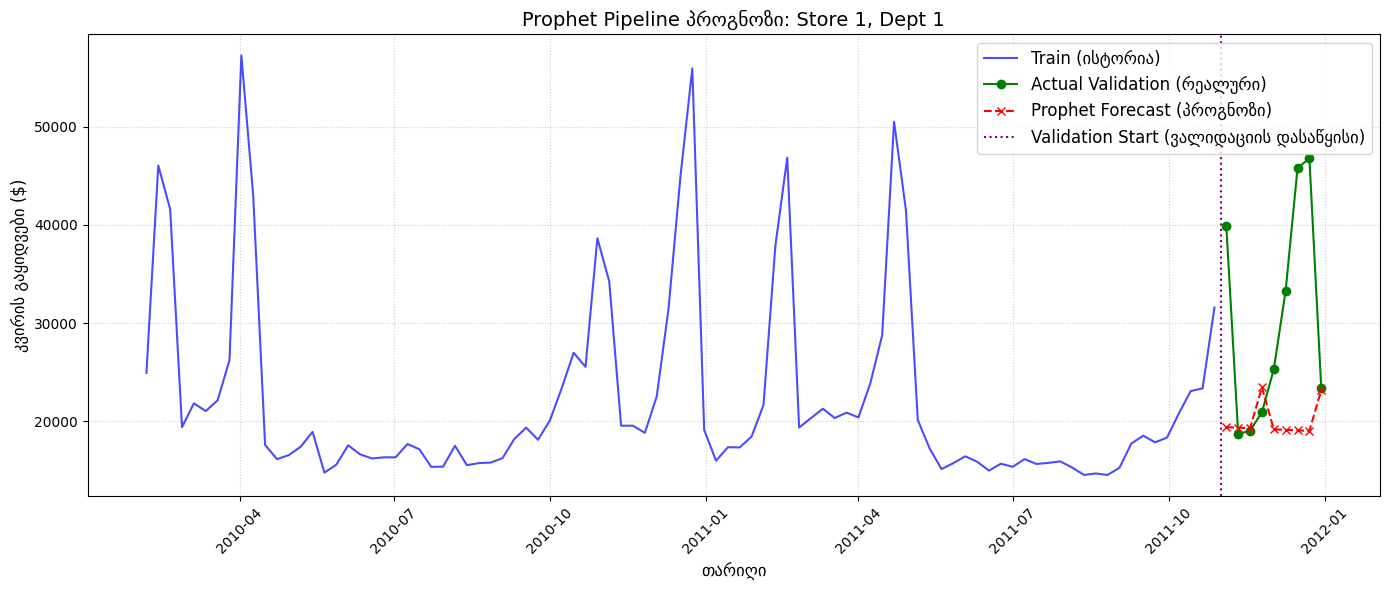

In [46]:
import matplotlib.pyplot as plt

target_store = 1
target_dept = 1

# Prepare historical data from fit_part_hard
hist_plot = fit_part_hard[
    (fit_part_hard['Store'] == target_store) &
    (fit_part_hard['Dept'] == target_dept)
].copy()
hist_plot['Date'] = pd.to_datetime(hist_plot['Date'])
hist_plot = hist_plot.sort_values('Date')

# Prepare validation data (actual and predictions) from val_eval
val_plot_data = val_eval[
    (val_eval['Store'] == target_store) &
    (val_eval['Dept'] == target_dept)
].copy()
val_plot_data['Date'] = pd.to_datetime(val_plot_data['Date'])
val_plot_data = val_plot_data.sort_values('Date')

plt.figure(figsize=(14, 6))

# Plot historical data (last 26 weeks, similar to user's example if enough data)
if len(hist_plot) > 0:
    plt.plot(hist_plot['Date'], hist_plot['Weekly_Sales'], label='Train (ისტორია)', color='blue', alpha=0.7)

# Plot actual validation data
plt.plot(val_plot_data['Date'], val_plot_data['Weekly_Sales'], label='Actual Validation (რეალური)', color='green', marker='o')

# Plot model predictions for validation period
plt.plot(val_plot_data['Date'], val_plot_data['Weekly_Sales_Pred'], label='Prophet Forecast (პროგნოზი)', color='red', linestyle='--', marker='x')

# Add a vertical line to mark the start of the validation period
plt.axvline(x=cutoff_start, color='purple', linestyle=':', label='Validation Start (ვალიდაციის დასაწყისი)')

plt.title(f"Prophet Pipeline პროგნოზი: Store {target_store}, Dept {target_dept}", fontsize=14)
plt.xlabel("თარიღი", fontsize=12)
plt.ylabel("კვირის გაყიდვები ($)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()